<a href="https://colab.research.google.com/github/aa6910/BPhO-Computational-Challenge-2024/blob/main/linear_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Classification

For the first few questions, we're going to work with the following dataset.

Our goal will be to use the two features, $x_1$ and $x_2$, to classify the points: class 0 is purple, class 1 is yellow.

Text(0, 0.5, '$x_2$')

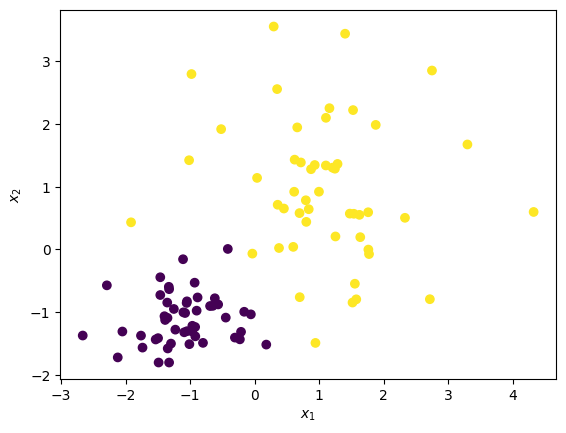

In [ ]:
import torch as t
import matplotlib.pyplot as plt
t.manual_seed(1) #Fix the random seed, so we always generate the same data.

N = 100
x_class_0 = 0.5*t.randn(N//2, 2) - 1
x_class_1 = t.randn(N//2, 2) + 1
X = t.cat([x_class_0, x_class_1], 0)
y = t.cat([t.zeros(N//2, 1), t.ones(N//2, 1)], 0)

plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

## 1) Numerical stability in computing the loss

First, we're going to compute the loss (i.e. minus the log-probability),
\begin{align}
  \mathcal{L} = -\sum_{i=1}^N (y_i \log \sigma(\mathbf{x}_i \mathbf{w}) + (1-y_i) \log \sigma(-\mathbf{x}_i \mathbf{w}))
\end{align}

#### 1.1) Compute the loss using the sigmoid
Write a function that takes a value for the weights as input, and returns the objective.  Use the most obvious approach, i.e. `t.sigmoid`.


In [ ]:
#Your code here



In [ ]:
# @title Answer

def loss_sigmoid(w):
    l = X@w
    return -(y*t.log(t.sigmoid(l)) + (1-y)*t.log(t.sigmoid(-l))).sum()

#### 1.2 Numerical instability in the naive loss.

The problem is that this form is numerically unstable.  Try
\begin{align}
\mathbf{w} = \begin{pmatrix} 20 \\ 20 \end{pmatrix}
\end{align}
You should get a NaN!

In [ ]:
#Your code here



In [ ]:
# @title Answer

w = 20*t.ones(2,1)
loss_sigmoid(w)

tensor(nan)

#### 1.3) log-sigmoid should be numerically stable.

The numerical instability should be fixable.  Plot
\begin{align}
 p = \log \sigma(\ell)
\end{align}
For $\ell$ between -100 and 100.

The plot should look very reasonable.  But note that the lower y's are `-inf`!

In [ ]:
#Your code here



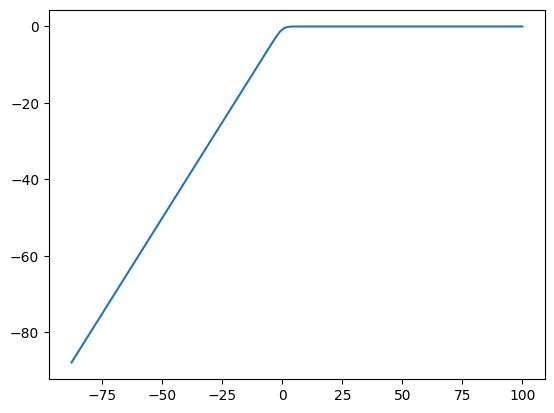

In [ ]:
# @title Answer

l = t.linspace(-100, 100, 100)
plt.plot(l, t.log(t.sigmoid(l)))

#### 1.4) Diagnose the problem

Work out why $\log \sigma(\ell)$ is having numerical issues for values of $x$ about -100.

In [ ]:
#Your code here



In [ ]:
# @title Answer

#The problem is that t.sigmoid(-100) is very close to zero.  In fact, its so
#close to zero that at some point, it numerically  underflows and becomes exactly zero,
print(t.sigmoid(t.tensor(-50)))
print(t.sigmoid(t.tensor(-100)))
#And log 0. is -inf
print(t.log(t.tensor(0.)))

tensor(1.9287e-22)
tensor(0.)
tensor(-inf)


#### 1.5 Use the numerically stable logsigmoid function

PyTorch implements a numerically stable `logsigmoid` function ([docs](https://pytorch.org/docs/stable/generated/torch.nn.functional.logsigmoid.html)).  Check that `logsigmoid` is indeed numerically stable.  Then implement the loss in terms of `logsigmoid`, and check that this loss is also numerically stable, specifically, that the loss works with,
\begin{align}
\mathbf{w} = \begin{pmatrix} 20 \\ 20 \end{pmatrix}
\end{align}

In [ ]:
#Your code here



In [ ]:
# @title Answer

print(t.nn.functional.logsigmoid(t.tensor(-100.)))
print(t.nn.functional.logsigmoid(t.tensor(-1000.)))

def loss(w):
    l = X@w
    return -(y*t.nn.functional.logsigmoid(l) + (1-y)*t.nn.functional.logsigmoid(-l)).sum()

print(loss(20*t.ones(2,1)))

tensor(-100.)
tensor(-1000.)
tensor(44.4466)
